<a href="https://colab.research.google.com/github/0sinach1/fraud-detection-project/blob/main/Fraud_Detect.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fraud analysis project
This notebook explores and models online payment fraud using a real-world dataset.

## 1. Import Libraries
We start by importing the necessary Python libraries for data analysis and visualization.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
!pip install scikit-learn==1.3.2

In [2]:
# Install imbalanced-learn for SMOTE
!pip install imbalanced-learn xgboost --quiet

# Import additional libraries
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import xgboost as xgb

print("✅ Libraries installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 54.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
✅ Libraries installed successfully!


## 2. Load Dataset
Load the online payments dataset for analysis.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
file_path = "/content/drive/MyDrive/Datasets/online_payments.csv"
df = pd.read_csv(file_path)
print(df.head())

   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  


In [5]:
df.shape

(6362620, 11)

In [6]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [7]:
df.describe(include='all')

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6362620,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6362620,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
unique,NaN,5,NaN,6353307,NaN,NaN,2722362,NaN,NaN,NaN,NaN
top,NaN,CASH_OUT,NaN,C1902386530,NaN,NaN,C1286084959,NaN,NaN,NaN,NaN
freq,NaN,2237500,NaN,3,NaN,NaN,113,NaN,NaN,NaN,NaN
mean,2.433972e+02,NaN,1.798619e+05,NaN,8.338831e+05,8.551137e+05,NaN,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,NaN,6.038582e+05,NaN,2.888243e+06,2.924049e+06,NaN,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,NaN,0.000000e+00,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,NaN,1.338957e+04,NaN,0.000000e+00,0.000000e+00,NaN,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,NaN,7.487194e+04,NaN,1.420800e+04,0.000000e+00,NaN,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,NaN,2.087215e+05,NaN,1.073152e+05,1.442584e+05,NaN,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00


In [8]:
df['isFraud'].value_counts()

,count
isFraud,
0,6354407
1,8213


## 4. Data Visualization
Visualize transaction types, fraud distribution, and transaction amounts.

<Axes: xlabel='type'>

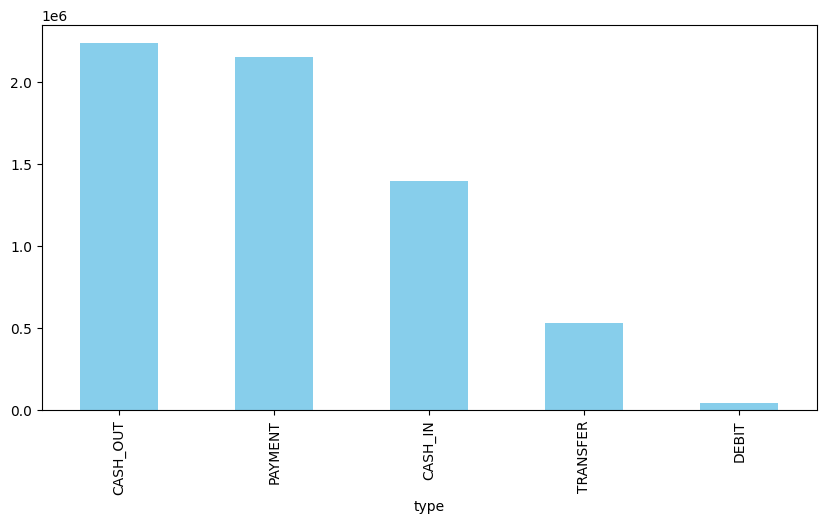

In [9]:
df['type'].value_counts().plot(kind='bar', figsize=(10, 5), color='skyblue')

<Axes: xlabel='type'>

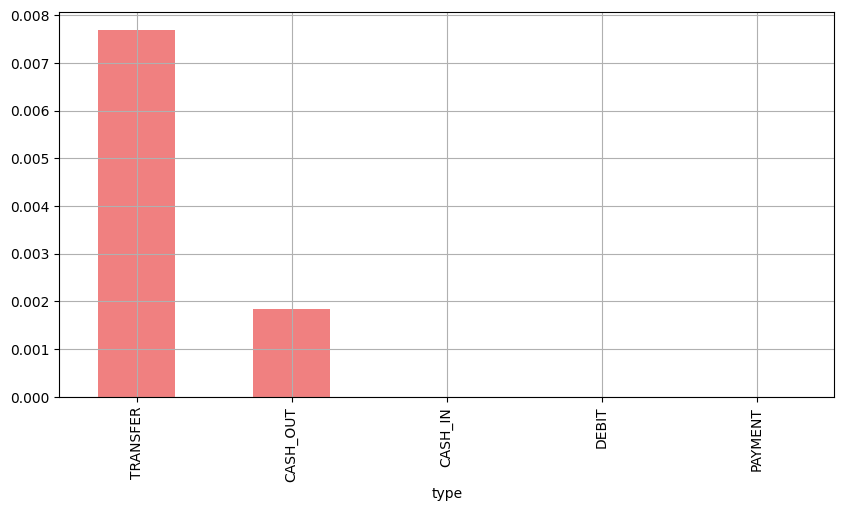

In [10]:
df.groupby('type')['isFraud'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(10, 5), color='lightcoral',grid=True)

In [11]:
df['amount'].describe().astype(int)

,amount
count,6362620
mean,179861
std,603858
min,0
25%,13389
50%,74871
75%,208721
max,92445516


<Axes: xlabel='amount', ylabel='Count'>

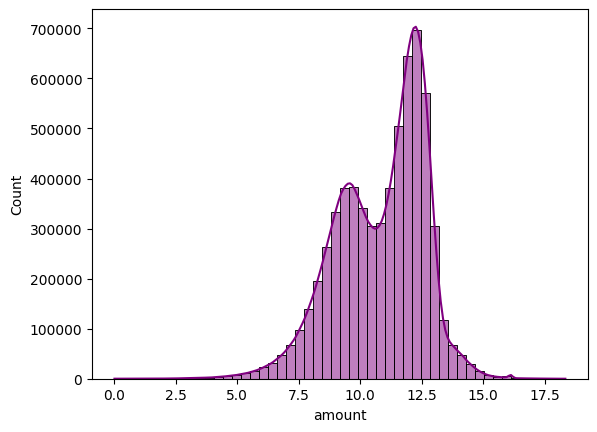

In [12]:
sns.histplot(np.log1p(df['amount']), bins=50, kde=True, color='purple', edgecolor='black')

## 5. Feature Engineering
Create new features and analyze their impact on fraud detection.

In [13]:
df['balanceDiffOrg'] = df['oldbalanceOrg'] - df['newbalanceOrig']
df['balanceDiffDest'] = df['newbalanceDest'] - df['oldbalanceDest']

In [14]:
(df['balanceDiffOrg'] < 0).sum()

1399253

In [15]:
(df['balanceDiffDest'] < 0).sum()

1238864

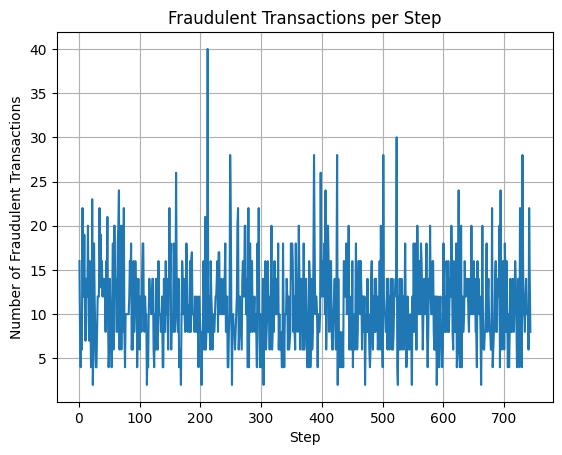

In [16]:
frauds_per_step = df[df['isFraud'] == 1]['step'].value_counts().sort_index()
plt.plot(frauds_per_step.index, frauds_per_step.values, label='Fraudulent Transactions')
plt.xlabel('Step')
plt.ylabel('Number of Fraudulent Transactions')
plt.title('Fraudulent Transactions per Step')
plt.grid(True)
plt.show()

In [17]:
df.drop(columns= 'step', inplace=True)

## 6. Top Senders and Receivers
Identify the most active senders and receivers in the dataset.

In [18]:
top_senders = df['nameOrig'].value_counts().head(10)

In [19]:
top_senders

,count
nameOrig,
C1902386530,3
C363736674,3
C545315117,3
C724452879,3
C1784010646,3
C1677795071,3
C1462946854,3
C1999539787,3
C2098525306,3


In [20]:
top_receivers = df['nameDest'].value_counts().head(10)

In [21]:
top_receivers

,count
nameDest,
C1286084959,113
C985934102,109
C665576141,105
C2083562754,102
C248609774,101
C1590550415,101
C451111351,99
C1789550256,99
C1360767589,98


## 7. Fraud Analysis by Type
Analyze fraud occurrences by transaction type.

In [22]:
fraud_types = df[df['type'].isin(['TRANSFER', 'CASH_OUT'])]

In [23]:
fraud_types['type'].value_counts()


,count
type,
CASH_OUT,2237500
TRANSFER,532909


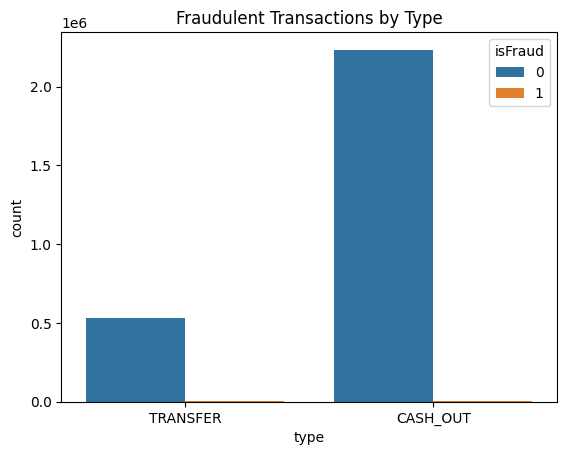

In [24]:
sns.countplot(data=fraud_types, x='type', hue='isFraud')
plt.title('Fraudulent Transactions by Type')
plt.show()

## 8. Correlation Analysis
Examine correlations between features and fraud.

In [25]:
corr = df[['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'isFraud']].corr()

In [26]:
corr

,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud
amount,1.000000,-0.002762,-0.007861,0.294137,0.459304,0.076688
oldbalanceOrg,-0.002762,1.000000,0.998803,0.066243,0.042029,0.010154
newbalanceOrig,-0.007861,0.998803,1.000000,0.067812,0.041837,-0.008148
oldbalanceDest,0.294137,0.066243,0.067812,1.000000,0.976569,-0.005885
newbalanceDest,0.459304,0.042029,0.041837,0.976569,1.000000,0.000535
isFraud,0.076688,0.010154,-0.008148,-0.005885,0.000535,1.000000


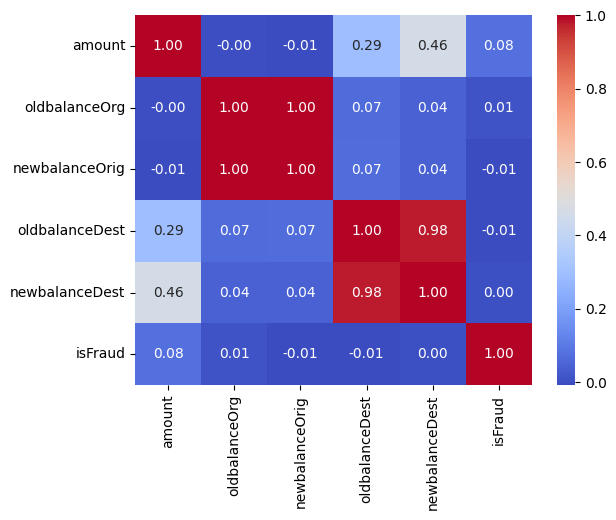

In [27]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

In [28]:
zero_after_transfer = df[
    (df['oldbalanceOrg'] > 0) &
    (df['newbalanceOrig'] == 0) &
    (df['type'].isin(['TRANSFER', 'CASH_OUT']))
]

In [29]:
len(zero_after_transfer)

1188074

In [30]:
zero_after_transfer.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
2,TRANSFER,181.00,C1305486145,181.0,0.0,C553264065,0.0,0.00,1,0,181.0,0.00
3,CASH_OUT,181.00,C840083671,181.0,0.0,C38997010,21182.0,0.00,1,0,181.0,-21182.00
15,CASH_OUT,229133.94,C905080434,15325.0,0.0,C476402209,5083.0,51513.44,0,0,15325.0,46430.44
19,TRANSFER,215310.30,C1670993182,705.0,0.0,C1100439041,22425.0,0.00,0,0,705.0,-22425.00
24,TRANSFER,311685.89,C1984094095,10835.0,0.0,C932583850,6267.0,2719172.89,0,0,10835.0,2712905.89


## 9. Data Preparation for Modeling
Prepare the data for machine learning by selecting features and splitting into train/test sets.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [32]:
df_model = df.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'], axis=1)

In [33]:
df_model.head()

,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,170136.0,160296.36,0.0,0.0,0,9839.64,0.0
1,PAYMENT,1864.28,21249.0,19384.72,0.0,0.0,0,1864.28,0.0
2,TRANSFER,181.00,181.0,0.00,0.0,0.0,1,181.00,0.0
3,CASH_OUT,181.00,181.0,0.00,21182.0,0.0,1,181.00,-21182.0
4,PAYMENT,11668.14,41554.0,29885.86,0.0,0.0,0,11668.14,0.0


## 10. Model Building
Build and train a logistic regression model to detect fraud.

In [34]:
categorical = ['type']
numeric = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

In [35]:
y = df_model['isFraud']
X = df_model.drop(columns=['isFraud'], axis=1)

In [36]:
X_test, X_train, y_test, y_train = train_test_split(X, y, test_size=0.3, stratify=y)

In [37]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric),
        ('cat', OneHotEncoder(drop='first'), categorical)
    ],
    remainder='drop'
)

In [38]:
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=1000))
])

In [39]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('prep', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains spa

## 11. Model Evaluation
Evaluate the model's performance using classification metrics and confusion matrix.

In [40]:
ypred = pipeline.predict(X_test)

In [41]:
print(classification_report(y_test, ypred))

              precision    recall  f1-score   support

           0       1.00      0.95      0.97   4448085
           1       0.02      0.95      0.04      5749

    accuracy                           0.95   4453834
   macro avg       0.51      0.95      0.51   4453834
weighted avg       1.00      0.95      0.97   4453834



In [42]:
confusion_matrix(y_test, ypred)

array([[4207278,  240807],
       [    312,    5437]])

In [43]:
print(f'This model has {round(pipeline.score(X_test, y_test), 2) * 100}% accuracy')

This model has 95.0% accuracy


In [44]:
df.head()

,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balanceDiffOrg,balanceDiffDest
0,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,9839.64,0.0
1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1864.28,0.0
2,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,181.00,0.0
3,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,181.00,-21182.0
4,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,11668.14,0.0


In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [46]:
# Step 1: Create preprocessor (same as before)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']
categorical_features = ['type']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

print("Preprocessing training data...")
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("✅ Preprocessing complete!")
print(f"X_train shape: {X_train_processed.shape}")
print(f"X_test shape: {X_test_processed.shape}")

Preprocessing training data...
✅ Preprocessing complete!
X_train shape: (4771965, 9)
X_test shape: (1590655, 9)


In [47]:
# Check class imbalance BEFORE SMOTE
print("BEFORE SMOTE:")
print(f"Legitimate transactions: {sum(y_train == 0):,}")
print(f"Fraud transactions: {sum(y_train == 1):,}")
print(f"Imbalance ratio: {sum(y_train == 0) / sum(y_train == 1):.0f}:1")

# Apply SMOTE to PREPROCESSED data
print("\nApplying SMOTE (this may take 2-3 minutes)...")
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

# Check class distribution AFTER SMOTE
print("\nAFTER SMOTE:")
print(f"Legitimate transactions: {sum(y_train_balanced == 0):,}")
print(f"Fraud transactions: {sum(y_train_balanced == 1):,}")
print(f"Imbalance ratio: {sum(y_train_balanced == 0) / sum(y_train_balanced == 1):.1f}:1")
print("\n✅ Data balanced!")

BEFORE SMOTE:
Legitimate transactions: 4,765,797
Fraud transactions: 6,168
Imbalance ratio: 773:1

Applying SMOTE (this may take 2-3 minutes)...

AFTER SMOTE:
Legitimate transactions: 4,765,797
Fraud transactions: 4,765,797
Imbalance ratio: 1.0:1

✅ Data balanced!


In [48]:
print("Training XGBoost model...")
import xgboost as xgb

model = xgb.XGBClassifier(
    max_depth=7,
    learning_rate=0.1,
    n_estimators=200,
    scale_pos_weight=1,  # Already balanced with SMOTE
    random_state=42,
    eval_metric='logloss',
    use_label_encoder=False
)

model.fit(X_train_balanced, y_train_balanced)
print("✅ Model trained successfully!")

Training XGBoost model...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:52:00] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ Model trained successfully!


In [49]:
# Make predictions on preprocessed test data
y_pred = model.predict(X_test_processed)
y_pred_proba = model.predict_proba(X_test_processed)[:, 1]

# Calculate metrics
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score

print("=" * 60)
print("MODEL PERFORMANCE (Threshold = 0.5)")
print("=" * 60)
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(f"True Negatives:  {cm[0,0]:,} (Correctly identified legitimate)")
print(f"False Positives: {cm[0,1]:,} (Wrongly flagged as fraud)")
print(f"False Negatives: {cm[1,0]:,} (Missed fraudsters)")
print(f"True Positives:  {cm[1,1]:,} (Caught fraudsters)")

# Calculate metrics
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print("\n" + "=" * 60)
print("KEY METRICS:")
print("=" * 60)
print(f"Precision: {precision:.3f} ({precision*100:.1f}%)")
print(f"Recall:    {recall:.3f} ({recall*100:.1f}%)")
print(f"F1-Score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print("=" * 60)


MODEL PERFORMANCE (Threshold = 0.5)
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00   1588610
       Fraud       0.33      0.99      0.50      2045

    accuracy                           1.00   1590655
   macro avg       0.67      1.00      0.75   1590655
weighted avg       1.00      1.00      1.00   1590655


Confusion Matrix:
True Negatives:  1,584,507 (Correctly identified legitimate)
False Positives: 4,103 (Wrongly flagged as fraud)
False Negatives: 12 (Missed fraudsters)
True Positives:  2,033 (Caught fraudsters)

KEY METRICS:
Precision: 0.331 (33.1%)
Recall:    0.994 (99.4%)
F1-Score:  0.497
ROC-AUC:   0.999


In [50]:
# Test different thresholds to optimize precision vs recall
print("Testing different thresholds...\n")

thresholds_to_test = [0.5, 0.6, 0.7, 0.8, 0.9]
results = []

for threshold in thresholds_to_test:
    # Apply threshold
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)

    # Calculate metrics
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    cm = confusion_matrix(y_test, y_pred_threshold)
    false_positives = cm[0, 1]
    false_negatives = cm[1, 0]
    true_positives = cm[1, 1]

    results.append({
        'threshold': threshold,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'false_positives': false_positives,
        'false_negatives': false_negatives,
        'true_positives': true_positives
    })

    print(f"Threshold {threshold}:")
    print(f"  Precision: {precision:.3f} ({precision*100:.1f}%) | Recall: {recall:.3f} ({recall*100:.1f}%)")
    print(f"  F1: {f1:.3f} | FP: {false_positives:,} | FN: {false_negatives} | TP: {true_positives:,}")
    print()

# Find best threshold (maximize F1)
best_result = max(results, key=lambda x: x['f1'])
print("=" * 70)
print(f"🎯 BEST THRESHOLD: {best_result['threshold']}")
print(f"   Precision: {best_result['precision']:.3f} ({best_result['precision']*100:.1f}%)")
print(f"   Recall: {best_result['recall']:.3f} ({best_result['recall']*100:.1f}%)")
print(f"   F1-Score: {best_result['f1']:.3f}")
print(f"   False Positives: {best_result['false_positives']:,}")
print(f"   False Negatives: {best_result['false_negatives']}")
print(f"   True Positives: {best_result['true_positives']:,}")
print("=" * 70)

Testing different thresholds...

Threshold 0.5:
  Precision: 0.331 (33.1%) | Recall: 0.994 (99.4%)
  F1: 0.497 | FP: 4,103 | FN: 12 | TP: 2,033

Threshold 0.6:
  Precision: 0.369 (36.9%) | Recall: 0.994 (99.4%)
  F1: 0.538 | FP: 3,474 | FN: 12 | TP: 2,033

Threshold 0.7:
  Precision: 0.420 (42.0%) | Recall: 0.994 (99.4%)
  F1: 0.590 | FP: 2,807 | FN: 13 | TP: 2,032

Threshold 0.8:
  Precision: 0.462 (46.2%) | Recall: 0.993 (99.3%)
  F1: 0.631 | FP: 2,364 | FN: 14 | TP: 2,031

Threshold 0.9:
  Precision: 0.514 (51.4%) | Recall: 0.990 (99.0%)
  F1: 0.676 | FP: 1,917 | FN: 21 | TP: 2,024

🎯 BEST THRESHOLD: 0.9
   Precision: 0.514 (51.4%)
   Recall: 0.990 (99.0%)
   F1-Score: 0.676
   False Positives: 1,917
   False Negatives: 21
   True Positives: 2,024


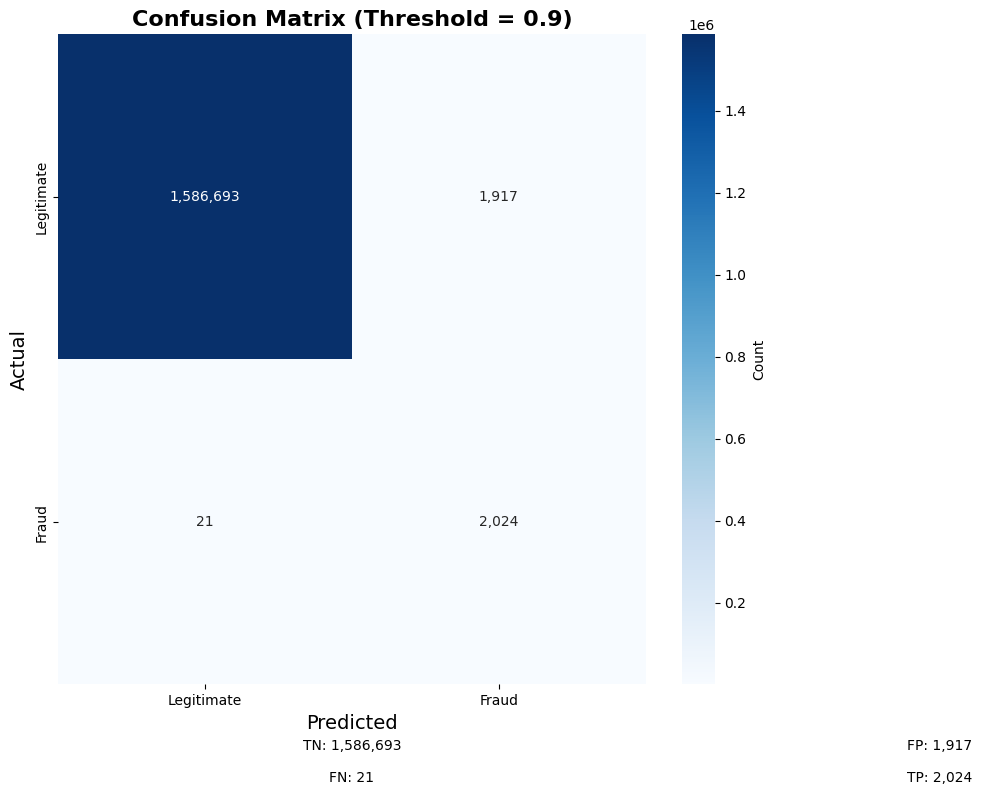

✅ Confusion matrix saved!


In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use best threshold
best_threshold = best_result['threshold']
y_pred_final = (y_pred_proba >= best_threshold).astype(int)
cm = confusion_matrix(y_test, y_pred_final)

# Create heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Legitimate', 'Fraud'],
            yticklabels=['Legitimate', 'Fraud'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix (Threshold = {best_threshold})', fontsize=16, fontweight='bold')
plt.ylabel('Actual', fontsize=14)
plt.xlabel('Predicted', fontsize=14)

# Add text annotations
total = cm.sum()
tn, fp, fn, tp = cm.ravel()
plt.text(0.5, -0.1, f'TN: {tn:,}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(1.5, -0.1, f'FP: {fp:,}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(0.5, -0.15, f'FN: {fn}', ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.text(1.5, -0.15, f'TP: {tp:,}', ha='center', transform=plt.gca().transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Confusion matrix saved!")

0.9986630253518213


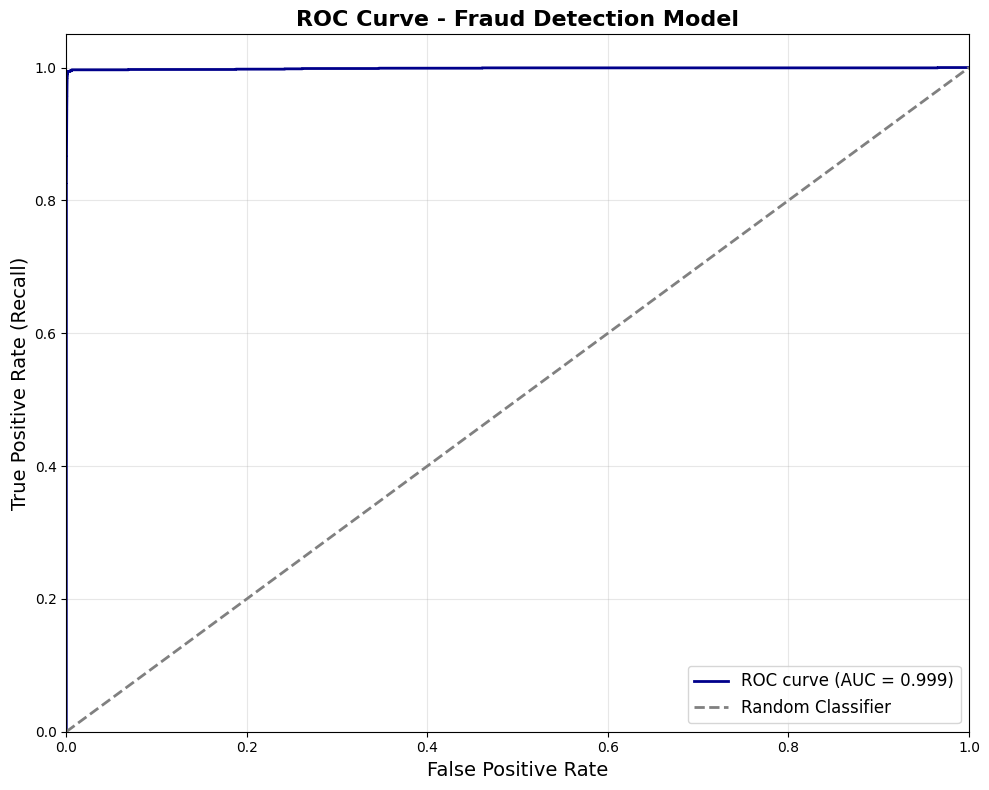

✅ ROC curve saved!


In [52]:
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
print(roc_auc)
# Plot
plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkblue', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate (Recall)', fontsize=14)
plt.title('ROC Curve - Fraud Detection Model', fontsize=16, fontweight='bold')
plt.legend(loc="lower right", fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ ROC curve saved!")

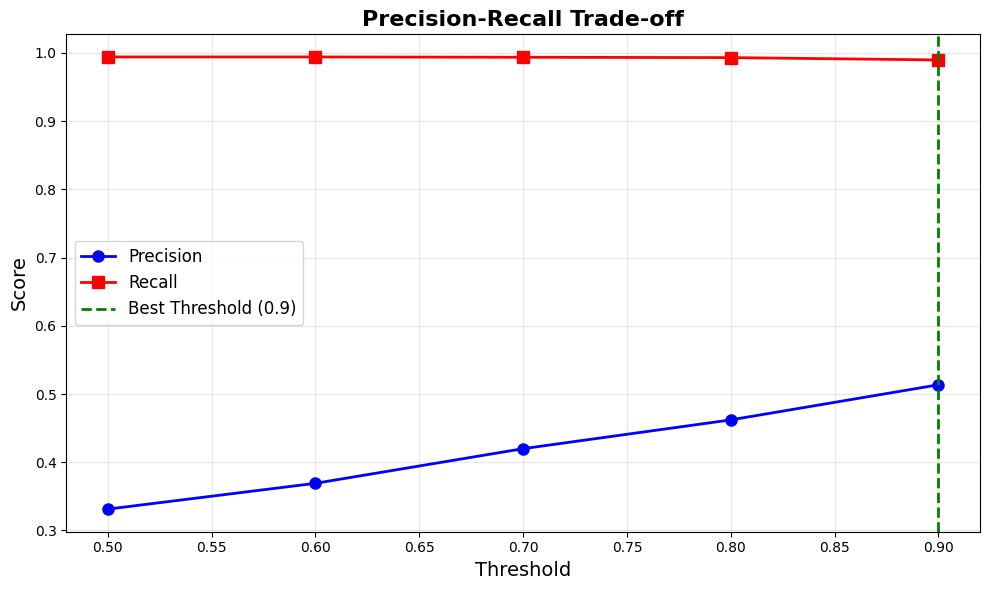

✅ Precision-Recall trade-off saved!


In [53]:
# Extract data from threshold testing
thresholds_list = [r['threshold'] for r in results]
precisions = [r['precision'] for r in results]
recalls = [r['recall'] for r in results]

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds_list, precisions, marker='o', linewidth=2, markersize=8, label='Precision', color='blue')
ax.plot(thresholds_list, recalls, marker='s', linewidth=2, markersize=8, label='Recall', color='red')
ax.axvline(x=best_threshold, color='green', linestyle='--', linewidth=2, label=f'Best Threshold ({best_threshold})')
ax.set_xlabel('Threshold', fontsize=14)
ax.set_ylabel('Score', fontsize=14)
ax.set_title('Precision-Recall Trade-off', fontsize=16, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_tradeoff.png', dpi=300, bbox_inches='tight')
plt.show()

print("✅ Precision-Recall trade-off saved!")

In [54]:
import joblib

joblib.dump(pipeline, 'model.pkl')
print("✅ Model saved as model.pkl")

✅ Model saved as model.pkl


In [55]:
from google.colab import files
files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>